In [2]:
import numpy as np
import pandas as pd

import yfinance as yf
import matplotlib.pyplot as plt


In [3]:
!pip3 install yfinance

[*********************100%***********************]  1 of 1 completed


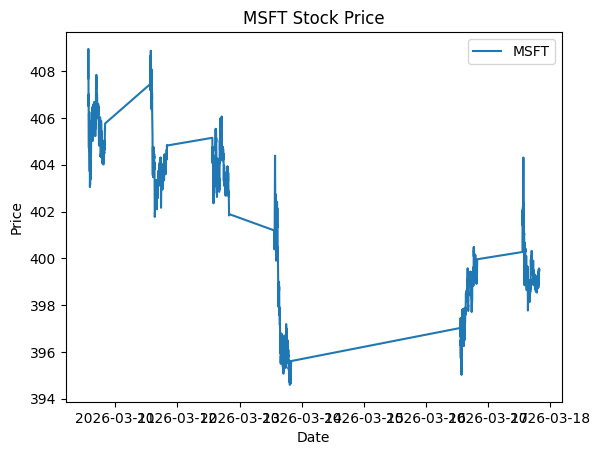

In [6]:
data = yf.download("MSFT", start="2026-03-10", end="2026-03-18", interval="1m");
closedata = data["Close"];
plt.plot(closedata)
plt.title("MSFT Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(["MSFT"])



[*********************100%***********************]  1 of 1 completed


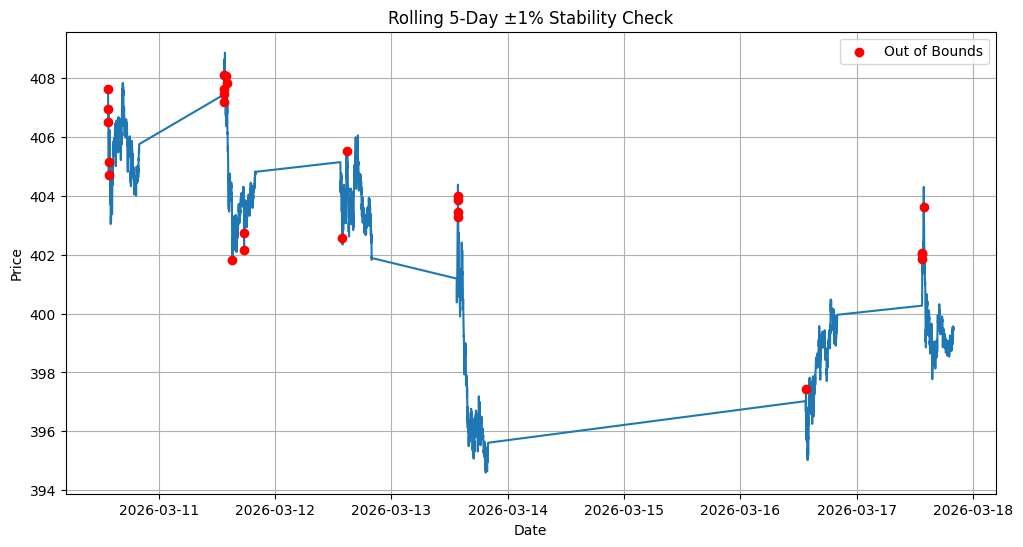

In [27]:
import pandas as pd
import yfinance as yf

data = yf.download("MSFT", start="2026-03-10", end="2026-03-18", interval="1m");

data = data[["Close"]]
data = data.dropna()

rolling_min = data.rolling(window = 5).min()
rolling_min = rolling_min.dropna()
rolling_max = data.rolling(window = 5).max()
rolling_max = rolling_max.dropna()

data["out_of_bounds"] = rolling_max > 1.004 * rolling_min

data = data.dropna()
data["out_of_bounds"]


plt.figure(figsize=(12,6))
plt.plot(data.index, data["Close"])

# Highlight out-of-bounds days
plt.scatter(
    data.index[data["out_of_bounds"]],
    data["Close"][data["out_of_bounds"]],
    color="red",
    label="Out of Bounds",
    zorder=3
)

plt.title( "Rolling 5-Day ±1% Stability Check")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

